# CpG / GC Composition vs MFPT Regression Analysis

This notebook investigates whether sperm-retained nucleosome MFPT differences relative to controls
are driven by DNA composition (GC%, CpG density, CpG O/E) or by something beyond composition.

**Strategy**
1. Load MFPT summaries for all groups (one parameter set: `k=1, p=0, c=0`).
2. Load FASTA sequences; compute per-nucleosome composition features:
   - GC fraction
   - $\rho_{\text{CpG}} = N_{\text{CpG}} / 146$ (CpG per nucleosome position)
   - $\text{CpG}_{O/E} = N_{\text{CpG}} \cdot L / (N_C \cdot N_G)$
3. Join MFPT ↔ sequence features by nucleosome ID.
4. Scatter: CpG density vs GC, coloured by group (ret_single_nuc vs ctrl04).
5. OLS regression: $\log_{10}(\text{MFPT}) = a + b_1 \text{GC} + b_2 \rho_{\text{CpG}} + b_3 \text{CpG}_{O/E} + \varepsilon$.
6. Residual distributions per group — if residuals still separate, MFPT carries signal beyond composition.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT = Path("/home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis")
SEQ_ROOT  = ROOT / "hamnucret_data/SPRM_IN_SEQ"
CLUSTER_MFPT_ROOT = ROOT / "cluster_output/markov_output"

# Parameter set to use throughout
PARAM_DIR = "k1.0_p100.0_c4.5_tau10000_ode__d90673"

print("Imports OK")

Imports OK


## 1. Dataset manifest

Each entry maps a group label to:
- `mfpt_tsv` — the MFPT summary file
- `fa` — the FASTA file with 147-bp nucleosome sequences
- `bed` — BED file (used only for coordinate-ID groups)
- `id_style` — how the MFPT `id` column links to the FASTA header:
  - `'coord'`: MFPT id = `chr:start-end`; FASTA header starts with `>chr:start-end`
  - `'name'`: MFPT id = some named peak ID that appears literally in the FASTA header

In [2]:
GROUPS = {
    "ctrl01": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ctrl01_random_genome_safe" / PARAM_DIR / "summaries/ctrl01_random_genome_safe.tsv",
        fa       = SEQ_ROOT / "SOM_data/control_sets/ctrl01_random_genome_safe/ctrl01.fa",
        id_style = "coord",
    ),
    "ctrl02": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ctrl02_random_genome_gcmatched" / PARAM_DIR / "summaries/ctrl02_random_genome_gcmatched.tsv",
        fa       = SEQ_ROOT / "SOM_data/control_sets/ctrl02_random_genome_gcmatched/ctrl02.fa",
        id_style = "coord",
    ),
    "ctrl03": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ctrl03_som_gcmatched" / PARAM_DIR / "summaries/ctrl03_som_gcmatched.tsv",
        fa       = SEQ_ROOT / "SOM_data/control_sets/ctrl03_som_gcmatched/ctrl03.fa",
        id_style = "name",
    ),
    "ctrl04": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ctrl04_bound_prom_evicted" / PARAM_DIR / "summaries/ctrl04_bound_prom_evicted.tsv",
        fa       = SEQ_ROOT / "SOM_data/control_sets/ctrl04_bound_prom_evicted/ctrl04.fa",
        id_style = "name",
    ),
    "ctrl05": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ctrl05_unbound_prom_random" / PARAM_DIR / "summaries/ctrl05_unbound_prom_random.tsv",
        fa       = SEQ_ROOT / "SOM_data/control_sets/ctrl05_unbound_prom_yazdi/ctrl05.fa",
        id_style = "name",
    ),
    "ret_single_nuc": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ret_single_nuc" / PARAM_DIR / "summaries/ret_single_nuc.tsv",
        fa       = SEQ_ROOT / "RET_data/single_nuc/pooled_peaks_single_nuc_nuc147.fa",
        id_style = "name",
    ),
    "ret_intermediate_nuc": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ret_intermediate_nuc" / PARAM_DIR / "summaries/ret_intermediate_nuc.tsv",
        fa       = SEQ_ROOT / "RET_data/intermediate/pooled_peaks_intermediate_nuc147.fa",
        id_style = "name",
    ),
    "ret_broad_nuc": dict(
        mfpt_tsv = CLUSTER_MFPT_ROOT / "ret_broad_nuc" / PARAM_DIR / "summaries/ret_broad_nuc.tsv",
        fa       = SEQ_ROOT / "RET_data/broad_ambiguous/pooled_peaks_broad_ambiguous_nuc147.fa",
        id_style = "name",
    ),
}

# Quick sanity check
for grp, cfg in GROUPS.items():
    ok_mfpt = cfg["mfpt_tsv"].exists()
    ok_fa   = cfg["fa"].exists()
    print(f"{grp:25s}  mfpt={'OK' if ok_mfpt else 'MISSING':7s}  fa={'OK' if ok_fa else 'MISSING'}")

ctrl01                     mfpt=OK       fa=OK
ctrl02                     mfpt=OK       fa=OK
ctrl03                     mfpt=OK       fa=OK
ctrl04                     mfpt=OK       fa=OK
ctrl05                     mfpt=OK       fa=OK
ret_single_nuc             mfpt=OK       fa=OK
ret_intermediate_nuc       mfpt=OK       fa=OK
ret_broad_nuc              mfpt=OK       fa=OK


## 2. Load FASTA → compute sequence features

In [3]:
def parse_fasta(fa_path, id_style):
    """
    Parse a FASTA file and return a dict {lookup_key: sequence}.

    For id_style='coord': key = 'chr:start-end' (first '|'-field or whole header)
    For id_style='name':  key = the named peak id found in the header
                          (second '|'-field if present, else first word)
    """
    records = {}
    current_key = None
    seq_parts = []

    with open(fa_path) as fh:
        for line in fh:
            line = line.rstrip()
            if not line:
                continue
            if line.startswith(">"):
                if current_key is not None:
                    records[current_key] = "".join(seq_parts).upper()
                header = line[1:]  # strip '>'
                parts  = header.split("|")
                if id_style == "coord":
                    # e.g. 'chr1:68905-69052' or 'chr1:68905-69052|ctrl01_X|...'
                    current_key = parts[0].strip()
                else:
                    # 'name' style
                    if len(parts) >= 2:
                        # e.g. 'chr4:165377403-165377550|ctrl04_0|NOS:...' → key='ctrl04_0'
                        current_key = parts[1].strip()
                    else:
                        # e.g. 'pooled_peak_1' (no pipe)
                        current_key = parts[0].strip()
                seq_parts = []
            else:
                seq_parts.append(line)

    if current_key is not None:
        records[current_key] = "".join(seq_parts).upper()

    return records


def sequence_features(seq):
    """Return GC, rho_CpG, CpG_OE for a nucleosome sequence."""
    L = len(seq)
    if L == 0:
        return np.nan, np.nan, np.nan

    nG  = seq.count("G")
    nC  = seq.count("C")
    nCpG = sum(1 for i in range(L - 1) if seq[i] == "C" and seq[i+1] == "G")

    gc       = (nG + nC) / L
    rho_cpg  = nCpG / L          # per-bp; often written as N_CpG / 146
    cpg_oe   = (nCpG * L) / (nC * nG) if (nC > 0 and nG > 0) else np.nan

    return gc, rho_cpg, cpg_oe


print("Helpers defined")

Helpers defined


In [4]:
def load_group(grp, cfg):
    """Load MFPT + sequence features for one group; return tidy DataFrame."""
    # ── MFPT ──────────────────────────────────────────────────────────────
    mfpt_df = pd.read_csv(cfg["mfpt_tsv"], sep="\t")
    # Drop infinite / NaN MFPT
    mfpt_df = mfpt_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["mfpt"])
    mfpt_df["log10_mfpt"] = np.log10(mfpt_df["mfpt"])

    # ── FASTA ─────────────────────────────────────────────────────────────
    fa_dict = parse_fasta(cfg["fa"], cfg["id_style"])

    # ── Compute features ──────────────────────────────────────────────────
    rows = []
    for _, row in mfpt_df.iterrows():
        nuc_id = str(row["id"])
        seq    = fa_dict.get(nuc_id)
        if seq is None:
            continue
        gc, rho, oe = sequence_features(seq)
        rows.append({
            "group"      : grp,
            "nuc_id"     : nuc_id,
            "mfpt"       : row["mfpt"],
            "log10_mfpt" : row["log10_mfpt"],
            "gc"         : gc,
            "rho_cpg"    : rho,
            "cpg_oe"     : oe,
        })

    df = pd.DataFrame(rows)
    n_mfpt  = len(mfpt_df)
    n_fa    = len(fa_dict)
    n_match = len(df)
    print(f"  {grp:25s}  mfpt={n_mfpt:5d}  fa={n_fa:5d}  matched={n_match:5d}")
    return df


all_dfs = []
for grp, cfg in GROUPS.items():
    df = load_group(grp, cfg)
    all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal rows: {len(data):,}")
data.head()

  ctrl01                     mfpt=20000  fa=20000  matched=20000
  ctrl02                     mfpt=11402  fa= 7905  matched=11402
  ctrl03                     mfpt=49341  fa=49342  matched=49341
  ctrl04                     mfpt=20000  fa=20000  matched=20000
  ctrl05                     mfpt=20000  fa=20000  matched=20000
  ret_single_nuc             mfpt=14517  fa=14517  matched=14517
  ret_intermediate_nuc       mfpt= 6339  fa= 6339  matched= 6339
  ret_broad_nuc              mfpt= 6922  fa= 6922  matched= 6922

Total rows: 148,521


,group,nuc_id,mfpt,log10_mfpt,gc,rho_cpg,cpg_oe
0,ctrl01,chr1:21646758-21646905,1922.768646,3.283927,0.571429,0.000000,0.000000
1,ctrl01,chr1:21679122-21679269,61.551498,1.789239,0.394558,0.006803,0.218750
2,ctrl01,chr1:2177140-2177287,511.067053,2.708478,0.598639,0.027211,0.316981
3,ctrl01,chr1:2177197-2177344,11192.951037,4.048945,0.625850,0.047619,0.544157
4,ctrl01,chr1:21890435-21890582,9612.581763,3.982840,0.625850,0.040816,0.482759


## 3. GC% distribution per group

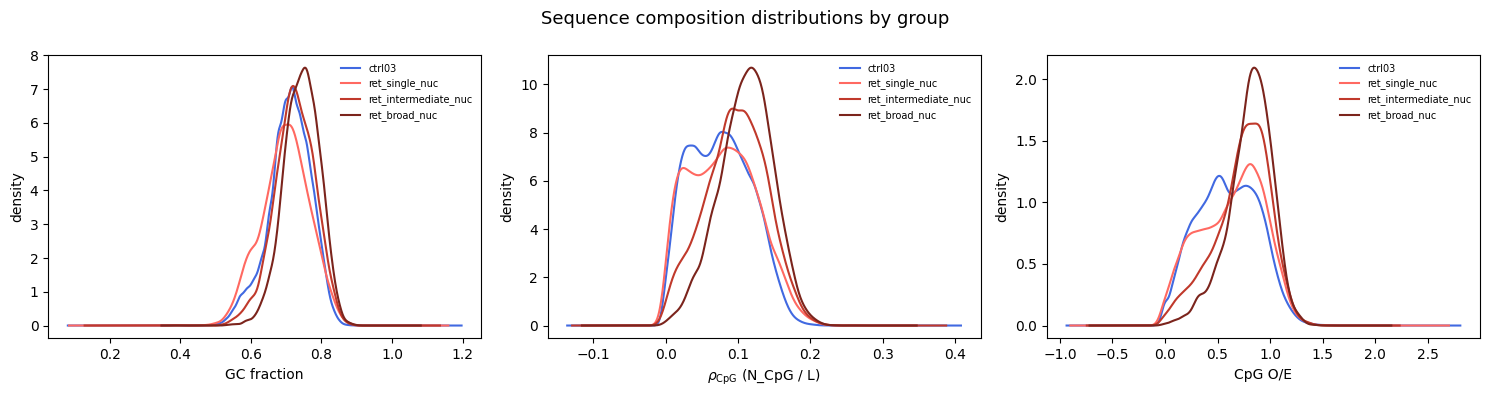

In [10]:
GROUP_COLORS = {
    # "ctrl01"              : "#aec6cf",
    # "ctrl02"              : "#77b5fe",
    "ctrl03"              : "#4169e1",
    # "ctrl04"              : "#0047ab",
    # "ctrl05"              : "#003366",
    "ret_single_nuc"      : "#ff6961",
    "ret_intermediate_nuc": "#c0392b",
    "ret_broad_nuc"       : "#7b241c",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features  = [("gc", "GC fraction"), ("rho_cpg", r"$\rho_{\mathrm{CpG}}$ (N_CpG / L)"),
             ("cpg_oe", "CpG O/E")]

for ax, (feat, label) in zip(axes, features):
    for grp, color in GROUP_COLORS.items():
        vals = data.loc[data.group == grp, feat].dropna()
        if len(vals) == 0:
            continue
        vals.plot.kde(ax=ax, color=color, label=grp, lw=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    ax.legend(fontsize=7, frameon=False)

fig.suptitle("Sequence composition distributions by group", fontsize=13)
plt.tight_layout()
plt.show()

## 4. CpG density vs GC — retained vs ctrl04

Key comparison: do retained sites have higher $\rho_{\text{CpG}}$ at *similar* GC?

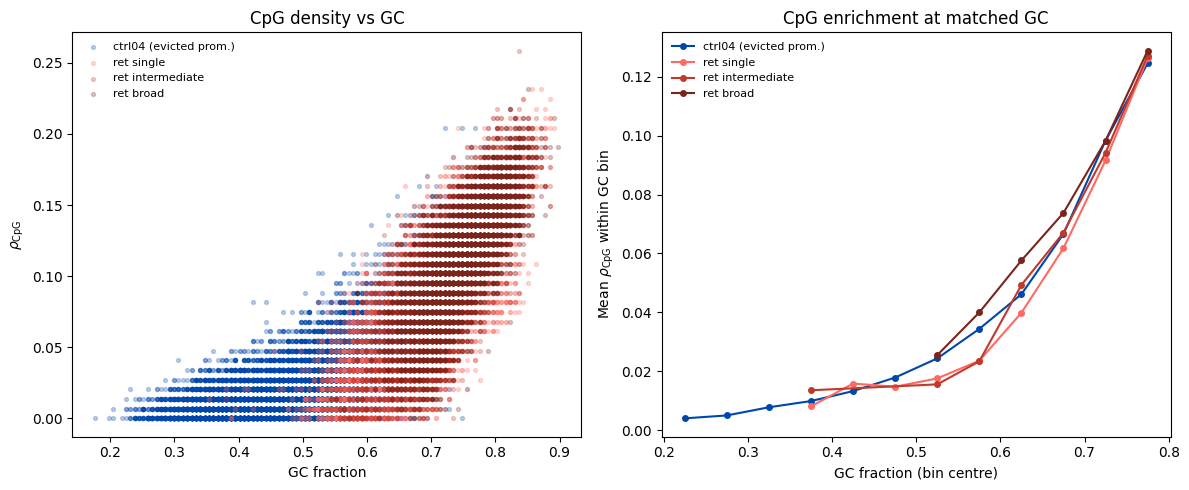

In [19]:
focus_groups = ["ctrl04", "ret_single_nuc", "ret_intermediate_nuc", "ret_broad_nuc"]
focus_labels = {"ctrl04": "ctrl04 (evicted prom.)",
                "ret_single_nuc": "ret single",
                "ret_intermediate_nuc": "ret intermediate",
                "ret_broad_nuc": "ret broad"}
focus_colors = {g: GROUP_COLORS[g] for g in focus_groups}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter GC vs rho_CpG
ax = axes[0]
for grp in focus_groups:
    sub = data[data.group == grp]
    ax.scatter(sub["gc"], sub["rho_cpg"],
               color=focus_colors[grp], alpha=0.25, s=8,
               label=focus_labels[grp], rasterized=True)
ax.set_xlabel("GC fraction")
ax.set_ylabel(r"$\rho_{\mathrm{CpG}}$")
ax.set_title("CpG density vs GC")
ax.legend(fontsize=8, frameon=False)

# Right: binned mean rho_CpG vs GC bin
ax = axes[1]
gc_bins = np.linspace(0.2, 0.8, 13)
gc_mid  = 0.5 * (gc_bins[:-1] + gc_bins[1:])
for grp in focus_groups:
    sub  = data[data.group == grp].copy()
    sub["gc_bin"] = pd.cut(sub["gc"], bins=gc_bins, labels=gc_mid)
    binned = sub.groupby("gc_bin", observed=True)["rho_cpg"].mean()
    ax.plot(binned.index.astype(float), binned.values,
            color=focus_colors[grp], marker="o", ms=4, lw=1.5,
            label=focus_labels[grp])
ax.set_xlabel("GC fraction (bin centre)")
ax.set_ylabel(r"Mean $\rho_{\mathrm{CpG}}$ within GC bin")
ax.set_title("CpG enrichment at matched GC")
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

## 5. OLS regression: log₁₀(MFPT) ∼ GC + ρ_CpG + CpG_O/E

In [20]:
# Fit on all groups combined, drop any NaN in predictors
reg_data = data.dropna(subset=["log10_mfpt", "gc", "rho_cpg", "cpg_oe"]).copy()

# Winsorise CpG O/E at 99th percentile to avoid leverage from outliers
oe_cap = reg_data["cpg_oe"].quantile(0.99)
reg_data["cpg_oe_w"] = reg_data["cpg_oe"].clip(upper=oe_cap)

formula = "log10_mfpt ~ gc + rho_cpg + cpg_oe_w"
model   = smf.ols(formula, data=reg_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log10_mfpt   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                 1.120e+05
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:50:11   Log-Likelihood:            -1.2354e+05
No. Observations:              148492   AIC:                         2.471e+05
Df Residuals:                  148488   BIC:                         2.471e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1578      0.009     17.380      0.0

In [21]:
reg_data["residual"] = model.resid
reg_data["fitted"]   = model.fittedvalues

# Attach residuals back to full data
data = data.merge(reg_data[["nuc_id", "group", "residual", "fitted"]],
                  on=["nuc_id", "group"], how="left")
print(f"Rows with residuals: {data['residual'].notna().sum():,}")

Rows with residuals: 156,964


## 6. Residual distributions — does MFPT carry signal beyond composition?

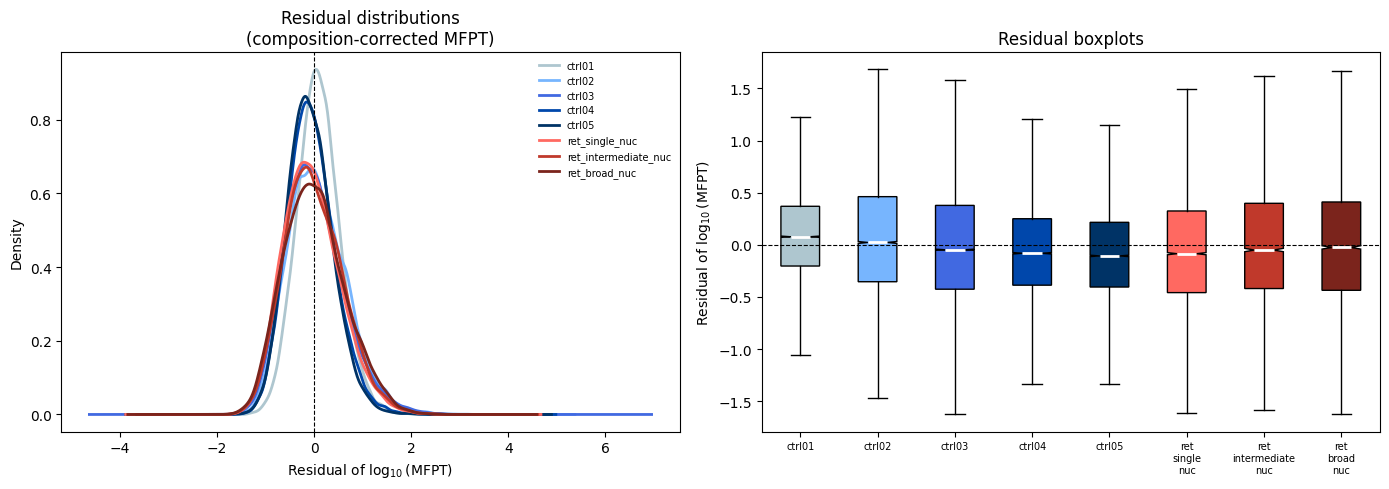

In [22]:
ordered_groups = ["ctrl01", "ctrl02", "ctrl03", "ctrl04", "ctrl05",
                  "ret_single_nuc", "ret_intermediate_nuc", "ret_broad_nuc"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: KDE of residuals ───────────────────────────────────────────────
ax = axes[0]
for grp in ordered_groups:
    vals = data.loc[data.group == grp, "residual"].dropna()
    if len(vals) < 10:
        continue
    vals.plot.kde(ax=ax, color=GROUP_COLORS[grp], label=grp, lw=2)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel(r"Residual of $\log_{10}$(MFPT)")
ax.set_ylabel("Density")
ax.set_title("Residual distributions\n(composition-corrected MFPT)")
ax.legend(fontsize=7, frameon=False)

# ── Right: boxplot ───────────────────────────────────────────────────────
ax = axes[1]
plot_data = [data.loc[data.group == g, "residual"].dropna().values
             for g in ordered_groups]
bp = ax.boxplot(plot_data, patch_artist=True, notch=True,
                medianprops=dict(color="white", lw=2), showfliers=False)
for patch, grp in zip(bp["boxes"], ordered_groups):
    patch.set_facecolor(GROUP_COLORS[grp])
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(range(1, len(ordered_groups) + 1))
ax.set_xticklabels([g.replace("_", "\n") for g in ordered_groups], fontsize=7)
ax.set_ylabel(r"Residual of $\log_{10}$(MFPT)")
ax.set_title("Residual boxplots")

plt.tight_layout()
plt.show()

## 7. Raw vs residual MFPT — side-by-side

TypeError: '>' not supported between instances of 'float' and 'NoneType'

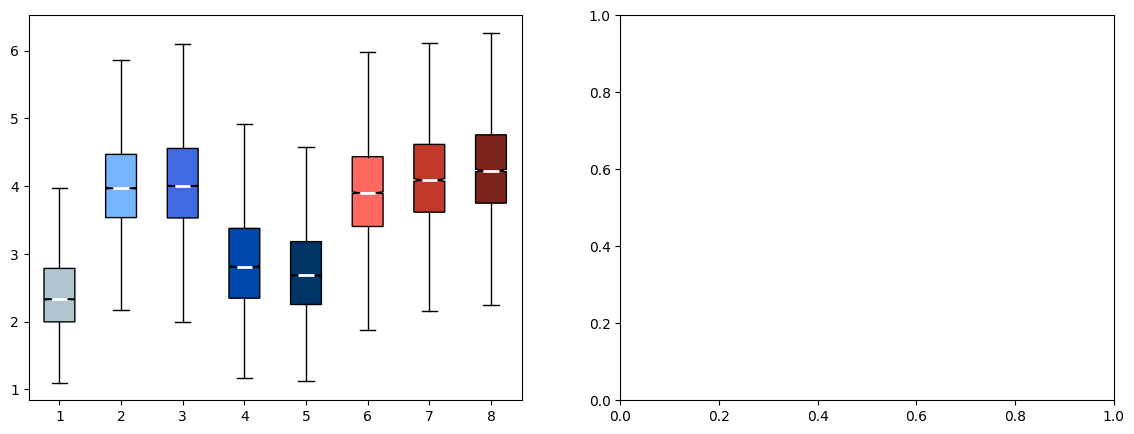

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "log10_mfpt", r"Raw $\log_{10}$(MFPT)"),
    (axes[1], "residual",   r"Composition-corrected residual"),
]:
    plot_data = [data.loc[data.group == g, col].dropna().values
                 for g in ordered_groups]
    bp = ax.boxplot(plot_data, patch_artist=True, notch=True,
                    medianprops=dict(color="white", lw=2), showfliers=False)
    for patch, grp in zip(bp["boxes"], ordered_groups):
        patch.set_facecolor(GROUP_COLORS[grp])
    ax.axhline(0 if col == "residual" else None,
               color="k", lw=0.8, ls="--")
    ax.set_xticks(range(1, len(ordered_groups) + 1))
    ax.set_xticklabels([g.replace("_", "\n") for g in ordered_groups], fontsize=7)
    ax.set_ylabel(title)
    ax.set_title(title)

plt.suptitle("Does separation survive composition correction?", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Pairwise Mann-Whitney U tests on residuals

In [24]:
from itertools import combinations
from scipy.stats import mannwhitneyu

results = []
for g1, g2 in combinations(ordered_groups, 2):
    x = data.loc[data.group == g1, "residual"].dropna()
    y = data.loc[data.group == g2, "residual"].dropna()
    if len(x) < 5 or len(y) < 5:
        continue
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    results.append({"group1": g1, "group2": g2, "U": stat, "p": p,
                    "median1": x.median(), "median2": y.median()})

mw_df = pd.DataFrame(results).sort_values("p")
mw_df["p_adj"] = mw_df["p"] * len(mw_df)  # Bonferroni
mw_df["p_adj"] = mw_df["p_adj"].clip(upper=1.0)
mw_df = mw_df.round(4)
print(mw_df.to_string(index=False))

              group1               group2           U      p  median1  median2  p_adj
              ctrl01               ctrl05 244186453.5 0.0000   0.0773  -0.1066 0.0000
              ctrl01               ctrl04 237261719.5 0.0000   0.0773  -0.0812 0.0000
              ctrl01       ret_single_nuc 169980158.0 0.0000   0.0773  -0.0853 0.0000
              ctrl01               ctrl03 554061897.0 0.0000   0.0773  -0.0475 0.0000
              ctrl02               ctrl05 226993471.0 0.0000   0.0224  -0.1066 0.0000
              ctrl02               ctrl04 221194039.0 0.0000   0.0224  -0.0812 0.0000
              ctrl02       ret_single_nuc 160179376.0 0.0000   0.0224  -0.0853 0.0000
              ctrl01 ret_intermediate_nuc  70938778.0 0.0000   0.0773  -0.0502 0.0000
              ctrl02               ctrl03 523026368.0 0.0000   0.0224  -0.0475 0.0000
              ctrl03               ctrl05 526190627.5 0.0000  -0.0475  -0.1066 0.0000
              ctrl01        ret_broad_nuc  76382784.0 

## 9. Composition summary table

In [25]:
summary = (
    data.groupby("group")[["gc", "rho_cpg", "cpg_oe", "log10_mfpt", "residual"]]
    .agg(["median", "std"])
    .round(4)
)
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reindex(ordered_groups)
print(summary.to_string())

                      gc_median  gc_std  rho_cpg_median  rho_cpg_std  cpg_oe_median  cpg_oe_std  log10_mfpt_median  log10_mfpt_std  residual_median  residual_std
group                                                                                                                                                            
ctrl01                   0.3878  0.1083          0.0068       0.0141         0.1635      0.2484             2.3292          0.6399           0.0773        0.4442
ctrl02                   0.6939  0.0443          0.0544       0.0370         0.4875      0.2844             3.9698          0.6819           0.0224        0.6020
ctrl03                   0.7143  0.0602          0.0748       0.0419         0.5945      0.2876             4.0046          0.7883          -0.0475        0.6123
ctrl04                   0.5238  0.1162          0.0204       0.0330         0.3760      0.2999             2.8106          0.7695          -0.0812        0.4879
ctrl05                   0.5

## 10. Interpretation guide

| Observation | Conclusion |
|---|---|
| Retained sites have higher $\rho_{\text{CpG}}$ at matched GC | CpG *organisation* (not just GC%) distinguishes retention |
| Raw MFPT separates, residuals **do not** | Separation is purely composition-driven |
| Raw MFPT separates, residuals **also** separate | Model captures something beyond simple composition — genuine kinetic/structural signal |
| Residuals for ctrl04 and ret_single_nuc overlap | CpG-rich promoter context is sufficient to explain the MFPT similarity |